In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()
    
def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [3]:
def set_seed(seed: int = 42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)

set_seed(42)

device = torch.device('cpu')
print('device:', device)

device: cpu


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

train_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)
class_names = train_full.classes

print('classes:', class_names)
print('n_classes:', len(class_names))
print('train_size:', len(train_full))
print('test_size:', len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
n_classes: 47
train_size: 112800
test_size: 18800


In [5]:
BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)
print(len(train_ds), len(train_ds) / len(train_full) * 100)
print(len(val_ds))

90240 80.0
22560


In [6]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

x_batch, y_batch = next(iter(train_loader))
print('x_batch:', x_batch.shape, x_batch.dtype, f'[{x_batch.min()}, {x_batch.max()}]')
print('y_batch:', y_batch.shape, y_batch.dtype, f'[{y_batch.min()}, {y_batch.max()}]')

x_batch: torch.Size([64, 1, 28, 28]) torch.float32 [-1.0, 1.0]
y_batch: torch.Size([64]) torch.int64 [0, 46]


In [7]:
class MLP(nn.Module):
  def __init__(
      self,
      input_dim: int = 28 * 28,
      hidden_dims: tuple = (256, 128),
      num_classes: int = 47,
      activation: str = 'relu',
      dropout_p: float = 0.0,
      use_batchnorm: bool = False
  ):
      super().__init__()

      act = activation.lower()
      if act == "relu":
          act_layer = nn.ReLU
      elif act == "tanh":
          act_layer = nn.Tanh
      elif act == "gelu":
          act_layer = nn.GELU
      else:
          raise ValueError(f"Unknown activation: {activation}")

      layers = [nn.Flatten()]

      prev = input_dim
      for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        if use_batchnorm:
          layers.append(nn.BatchNorm1d(h))
        layers.append(act_layer())
        if dropout_p > 0:
          layers.append(nn.Dropout(p=dropout_p))
        prev = h
      
      layers.append(nn.Linear(prev, num_classes))
      self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.2773, acc=0.6264 | val loss=0.8206, acc=0.7486
epoch 02/20 | train loss=0.7154, acc=0.7716 | val loss=0.6607, acc=0.7916
epoch 03/20 | train loss=0.5988, acc=0.8023 | val loss=0.6475, acc=0.7897
epoch 04/20 | train loss=0.5365, acc=0.8196 | val loss=0.5954, acc=0.8040
epoch 05/20 | train loss=0.4927, acc=0.8314 | val loss=0.5558, acc=0.8172
epoch 06/20 | train loss=0.4671, acc=0.8385 | val loss=0.5534, acc=0.8165
epoch 07/20 | train loss=0.4417, acc=0.8439 | val loss=0.5309, acc=0.8257
epoch 08/20 | train loss=0.4217, acc=0.8495 | val loss=0.5383, acc=0.8234
epoch 09/20 | train loss=0.4055, acc=0.8539 | val loss=0.5168, acc=0.8321
epoch 10/20 | train loss=0.3898, acc=0.8575 | val loss=0.5156, acc=0.8358
epoch 11/20 | train loss=0.3764, acc=0.8613 | val loss=0.5257, acc=0.8275
epoch 12/20 | train loss=0.3628, acc=0.8655 | val loss=0.5197, acc=0.8321
epoch 13/20 | train loss=0.3556, acc=0.8670 | val loss=0.5456, acc=0.8319
epoch 14/20 | train loss=0.3446, acc=0

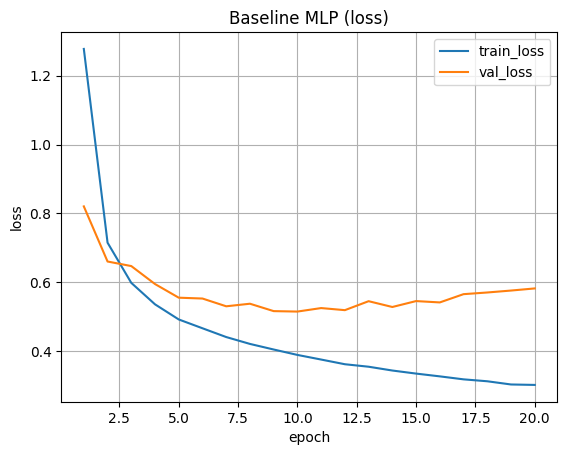

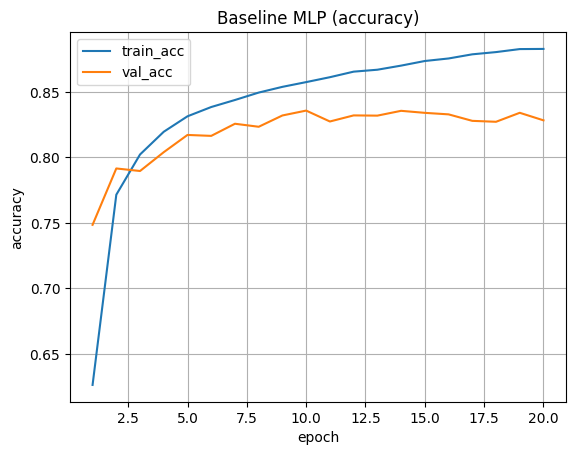

In [9]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128, 64)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
)
plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=1.9119, acc=0.4479 | val loss=1.0204, acc=0.6897
epoch 02/20 | train loss=1.2799, acc=0.6118 | val loss=0.8378, acc=0.7299
epoch 03/20 | train loss=1.1519, acc=0.6491 | val loss=0.7656, acc=0.7531
epoch 04/20 | train loss=1.0846, acc=0.6648 | val loss=0.7249, acc=0.7664
epoch 05/20 | train loss=1.0429, acc=0.6773 | val loss=0.6961, acc=0.7781
epoch 06/20 | train loss=1.0085, acc=0.6883 | val loss=0.6757, acc=0.7811
epoch 07/20 | train loss=0.9836, acc=0.6974 | val loss=0.6630, acc=0.7841
epoch 08/20 | train loss=0.9660, acc=0.7007 | val loss=0.6405, acc=0.7944
epoch 09/20 | train loss=0.9519, acc=0.7031 | val loss=0.6434, acc=0.7935
epoch 10/20 | train loss=0.9426, acc=0.7058 | val loss=0.6381, acc=0.7929
epoch 11/20 | train loss=0.9211, acc=0.7132 | val loss=0.6194, acc=0.7957
epoch 12/20 | train loss=0.9169, acc=0.7146 | val loss=0.6179, acc=0.8010
epoch 13/20 | train loss=0.9072, acc=0.7163 | val loss=0.6069, acc=0.8027
epoch 14/20 | train loss=0.9035, acc=0

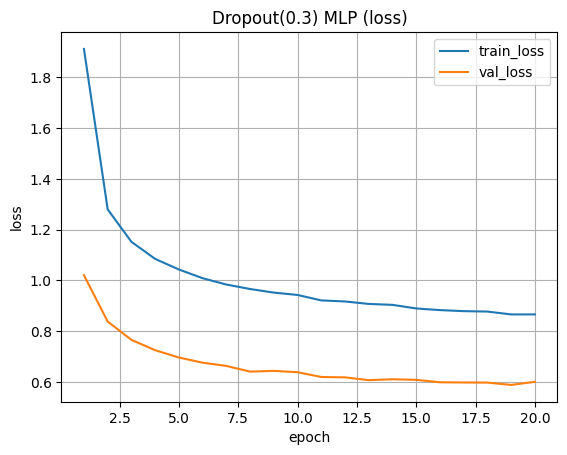

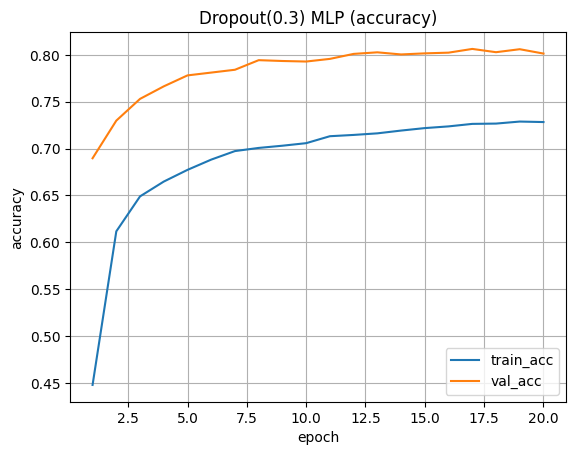

In [10]:
set_seed(42)

nn_dropout = MLP(hidden_dims=(256, 128, 64), dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(nn_dropout.parameters(), lr=1e-3)

history_nn_dropout = fit(
    nn_dropout, train_loader, val_loader,
    optimizer, criterion, device,
)

plot_history(history_nn_dropout, title="Dropout(0.3) MLP")

epoch 01/20 | train loss=1.0150, acc=0.7204 | val loss=0.5941, acc=0.8058
epoch 02/20 | train loss=0.5560, acc=0.8129 | val loss=0.5092, acc=0.8298
epoch 03/20 | train loss=0.4794, acc=0.8347 | val loss=0.4920, acc=0.8329
epoch 04/20 | train loss=0.4358, acc=0.8464 | val loss=0.4683, acc=0.8404
epoch 05/20 | train loss=0.4012, acc=0.8568 | val loss=0.4516, acc=0.8458
epoch 06/20 | train loss=0.3772, acc=0.8625 | val loss=0.4441, acc=0.8489
epoch 07/20 | train loss=0.3589, acc=0.8682 | val loss=0.4489, acc=0.8482
epoch 08/20 | train loss=0.3388, acc=0.8748 | val loss=0.4543, acc=0.8510
epoch 09/20 | train loss=0.3250, acc=0.8775 | val loss=0.4467, acc=0.8507
epoch 10/20 | train loss=0.3112, acc=0.8807 | val loss=0.4460, acc=0.8531
epoch 11/20 | train loss=0.2989, acc=0.8853 | val loss=0.4483, acc=0.8530
epoch 12/20 | train loss=0.2881, acc=0.8890 | val loss=0.4634, acc=0.8489
epoch 13/20 | train loss=0.2798, acc=0.8916 | val loss=0.4646, acc=0.8505
epoch 14/20 | train loss=0.2725, acc=0

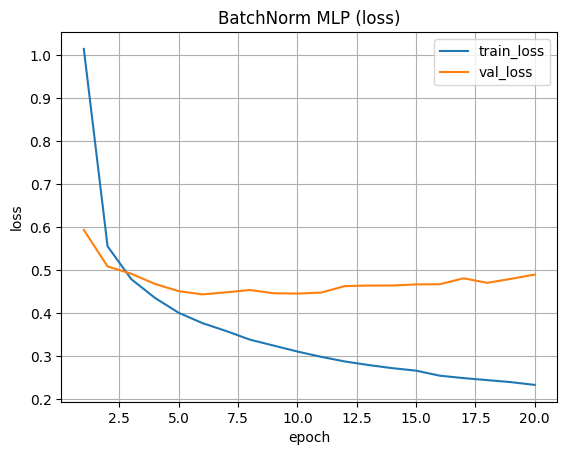

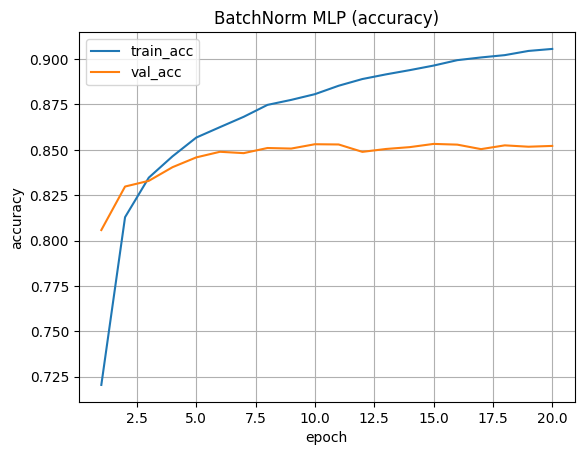

In [11]:
set_seed(42)

nn_batchnorm = MLP(hidden_dims=(256, 128, 64), use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(nn_batchnorm.parameters(), lr=1e-3)

history_nn_batchnorm = fit(
    nn_batchnorm, train_loader, val_loader,
    optimizer, criterion, device,
)

plot_history(history_nn_batchnorm, title="BatchNorm MLP")

In [12]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


epoch 01/20 | train loss=1.0150, acc=0.7204 | val loss=0.5941, acc=0.8058
epoch 02/20 | train loss=0.5560, acc=0.8129 | val loss=0.5092, acc=0.8298
epoch 03/20 | train loss=0.4794, acc=0.8347 | val loss=0.4920, acc=0.8329
epoch 04/20 | train loss=0.4358, acc=0.8464 | val loss=0.4683, acc=0.8404
epoch 05/20 | train loss=0.4012, acc=0.8568 | val loss=0.4516, acc=0.8458
epoch 06/20 | train loss=0.3772, acc=0.8625 | val loss=0.4441, acc=0.8489
epoch 07/20 | train loss=0.3589, acc=0.8682 | val loss=0.4489, acc=0.8482
epoch 08/20 | train loss=0.3388, acc=0.8748 | val loss=0.4543, acc=0.8510
epoch 09/20 | train loss=0.3250, acc=0.8775 | val loss=0.4467, acc=0.8507
epoch 10/20 | train loss=0.3112, acc=0.8807 | val loss=0.4460, acc=0.8531
epoch 11/20 | train loss=0.2989, acc=0.8853 | val loss=0.4483, acc=0.8530
epoch 12/20 | train loss=0.2881, acc=0.8890 | val loss=0.4634, acc=0.8489
epoch 13/20 | train loss=0.2798, acc=0.8916 | val loss=0.4646, acc=0.8505
epoch 14/20 | train loss=0.2725, acc=0

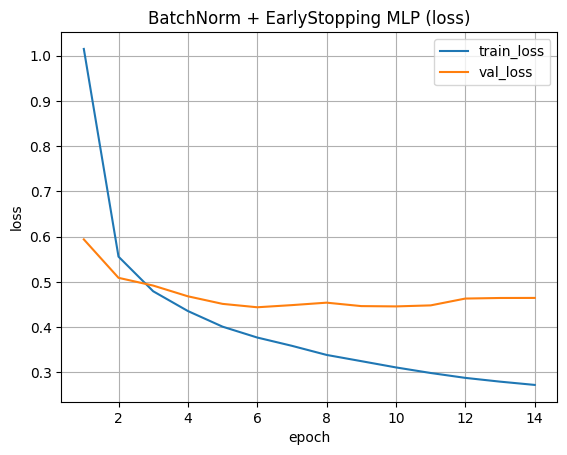

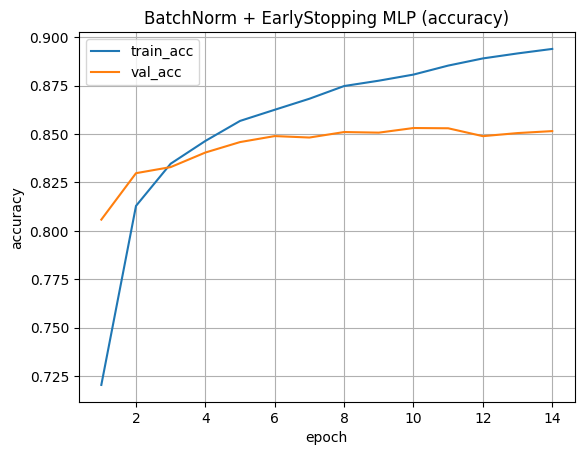

In [13]:
set_seed(42)

best_model = MLP(hidden_dims=(256, 128, 64), use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-3)
es = EarlyStopping(patience=4)

history_best_model = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device, early_stopping=es
)

plot_history(history_best_model, title="BatchNorm + EarlyStopping MLP")

In [15]:
torch.save(best_model.state_dict(), "./artifacts/best_model.pt")

In [16]:
import json

best_config = {
    "model": {
        "hidden_dims": [256, 128, 64],
        "dropout_p": 0.0,
        "use_batchnorm": True,
        "activation": "ReLU"
    },
    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": 5,
        "seed": 42
    },
    "dataset": {
        "name": "EMNIST",
        "train_size": len(train_ds),
        "val_size": len(val_ds),
        "test_size": len(test_ds),
        "num_classes": len(class_names)
    },
    "best_val_accuracy": max(history_best_model["val_acc"]),
    "best_val_loss": min(history_best_model["val_loss"])
}

with open("./artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)


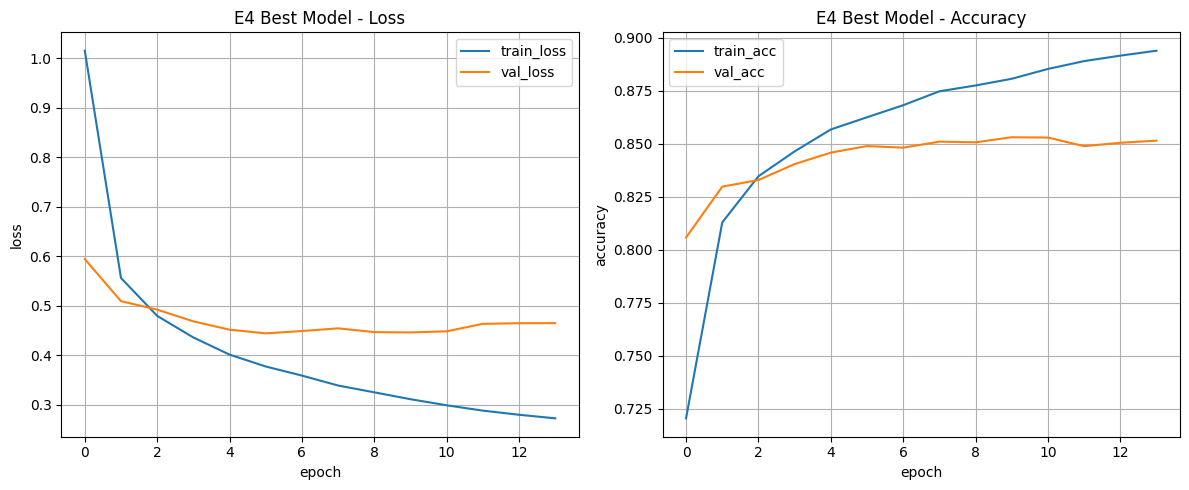

Финальная точность лучшей модели на тесте: 0.8513


In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_best_model["train_loss"], label="train_loss")
plt.plot(history_best_model["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("E4 Best Model - Loss")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_best_model["train_acc"], label="train_acc")
plt.plot(history_best_model["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("E4 Best Model - Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./artifacts/figures/curves_best.png", dpi=150)
plt.show()

test_acc = evaluate(best_model, test_loader, criterion, device)[1]
print(f"Финальная точность лучшей модели на тесте: {test_acc:.4f}")

In [ ]:
best_model = MLP(hidden_dims=(256, 128, 64), use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
es = EarlyStopping(patience=4)

epoch 01/6 | train loss=0.8225, acc=0.7420 | val loss=0.6664, acc=0.7832
epoch 02/6 | train loss=0.7239, acc=0.7689 | val loss=0.6775, acc=0.7812
epoch 03/6 | train loss=0.6888, acc=0.7779 | val loss=0.6143, acc=0.7942
epoch 04/6 | train loss=0.6597, acc=0.7855 | val loss=0.6103, acc=0.8051
epoch 05/6 | train loss=0.6271, acc=0.7962 | val loss=0.6054, acc=0.8069
epoch 06/6 | train loss=0.6226, acc=0.7973 | val loss=0.5902, acc=0.8116


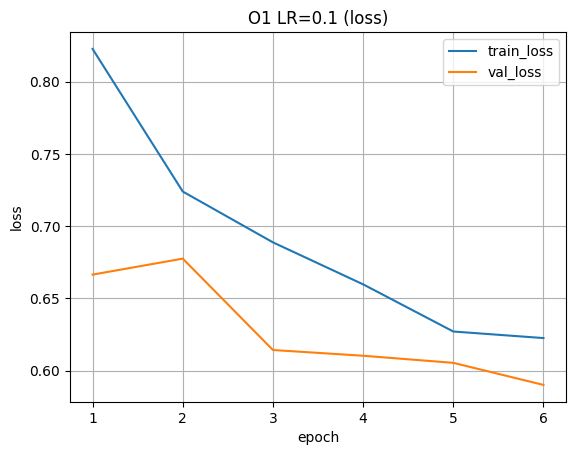

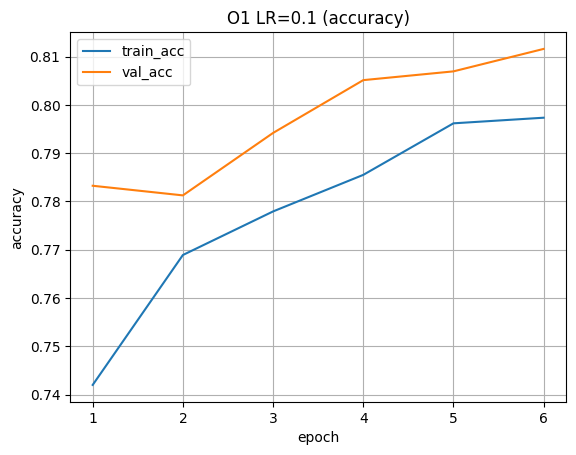

In [22]:
set_seed(42)

optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-1)

history_o1 = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device, epochs=6
)
plot_history(history_o1, title="O1 LR=0.1")
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

epoch 01/6 | train loss=0.5403, acc=0.8150 | val loss=0.5879, acc=0.8126
epoch 02/6 | train loss=0.5259, acc=0.8192 | val loss=0.5683, acc=0.8172
epoch 03/6 | train loss=0.5170, acc=0.8225 | val loss=0.5623, acc=0.8194
epoch 04/6 | train loss=0.5082, acc=0.8239 | val loss=0.5492, acc=0.8212
epoch 05/6 | train loss=0.4966, acc=0.8277 | val loss=0.5457, acc=0.8231
epoch 06/6 | train loss=0.4784, acc=0.8332 | val loss=0.5429, acc=0.8253


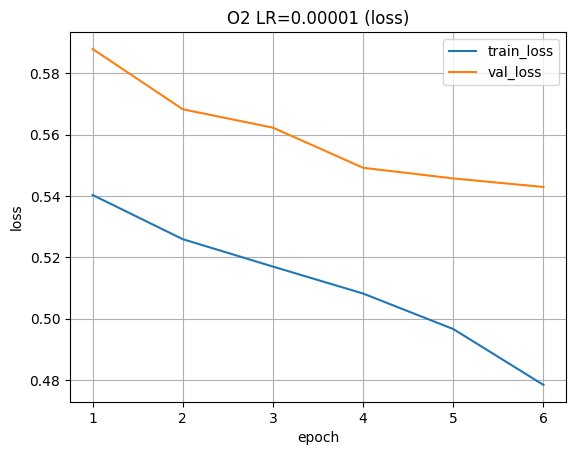

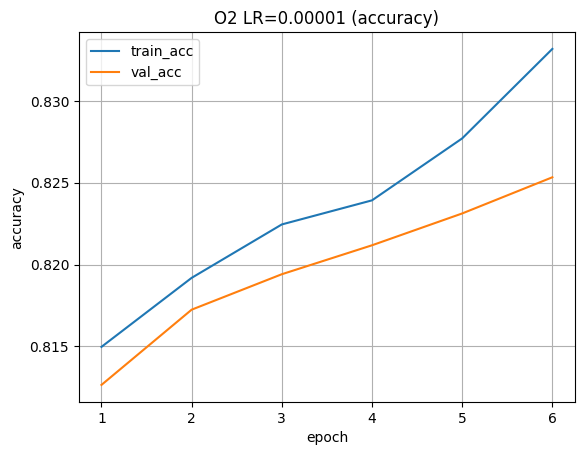

In [23]:
set_seed(42)

optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-5)

history_o2 = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device, epochs=6
)
plot_history(history_o2, title="O2 LR=0.00001")
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

epoch 01/10 | train loss=0.4393, acc=0.8452 | val loss=0.4893, acc=0.8391
epoch 02/10 | train loss=0.4365, acc=0.8469 | val loss=0.4890, acc=0.8376
epoch 03/10 | train loss=0.4381, acc=0.8466 | val loss=0.4878, acc=0.8386
epoch 04/10 | train loss=0.4360, acc=0.8464 | val loss=0.4861, acc=0.8382
epoch 05/10 | train loss=0.4320, acc=0.8474 | val loss=0.4862, acc=0.8390
epoch 06/10 | train loss=0.4210, acc=0.8507 | val loss=0.4887, acc=0.8392
epoch 07/10 | train loss=0.4395, acc=0.8458 | val loss=0.4862, acc=0.8400
epoch 08/10 | train loss=0.4403, acc=0.8459 | val loss=0.4845, acc=0.8396
epoch 09/10 | train loss=0.4352, acc=0.8467 | val loss=0.4886, acc=0.8377
epoch 10/10 | train loss=0.4364, acc=0.8456 | val loss=0.4866, acc=0.8387


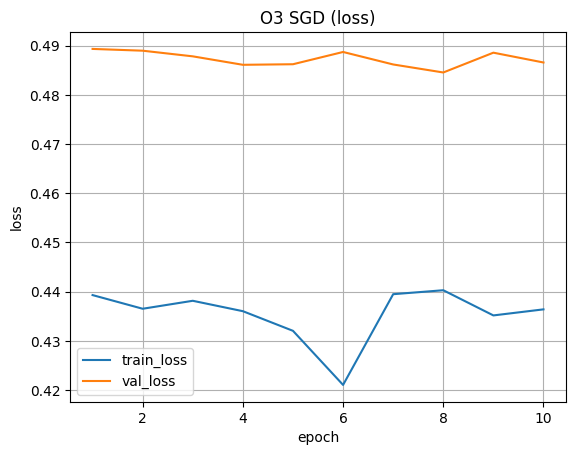

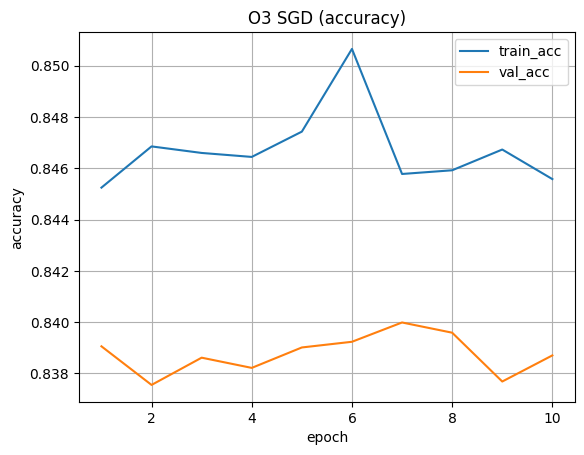

o3 test: loss=0.5038, acc=0.8342


In [29]:
set_seed(42)

optimizer = torch.optim.SGD(best_model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device, epochs=10
)

plot_history(history_o3, title='O3 SGD')
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"o3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [27]:
import pandas as pd
runs = [
    {
        "experiment_id": "E1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_baseline["train_loss"]),
        "best_val_accuracy": max(history_baseline["val_acc"]),
        "best_val_loss": min(history_baseline["val_loss"])
    },

    {
        "experiment_id": "E2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 dropout=0.3",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_nn_dropout["train_loss"]),
        "best_val_accuracy": max(history_nn_dropout["val_acc"]),
        "best_val_loss": min(history_nn_dropout["val_loss"])
    },

    {
        "experiment_id": "E3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 batchnorm",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_nn_batchnorm["train_loss"]),
        "best_val_accuracy": max(history_nn_batchnorm["val_acc"]),
        "best_val_loss": min(history_nn_batchnorm["val_loss"])
    },

    {
        "experiment_id": "E4",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 batchnorm earlystop",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_best_model["train_loss"]),
        "best_val_accuracy": max(history_best_model["val_acc"]),
        "best_val_loss": min(history_best_model["val_loss"])
    },

    {
        "experiment_id": "O1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_o1["train_loss"]),
        "best_val_accuracy": max(history_o1["val_acc"]),
        "best_val_loss": min(history_o1["val_loss"])
    },

    {
        "experiment_id": "O2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_o2["train_loss"]),
        "best_val_accuracy": max(history_o2["val_acc"]),
        "best_val_loss": min(history_o2["val_loss"])
    },

    {
        "experiment_id": "O3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs_trained": len(history_o3["train_loss"]),
        "best_val_accuracy": max(history_o3["val_acc"]),
        "best_val_loss": min(history_o3["val_loss"])
    }
]

runs_df = pd.DataFrame(runs)
runs_df.to_csv("./artifacts/runs.csv", index=False)
runs_df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,256-128-64,Adam,0.00100,0.0,0.0000,20,0.835783,0.515557
1,E2,EMNIST,42,256-128-64 dropout=0.3,Adam,0.00100,0.0,0.0000,20,0.806347,0.588079
2,E3,EMNIST,42,256-128-64 batchnorm,Adam,0.00100,0.0,0.0000,20,0.853267,0.444114
3,E4,EMNIST,42,256-128-64 batchnorm earlystop,Adam,0.00100,0.0,0.0000,14,0.853090,0.444114
4,O1,EMNIST,42,same as E4,Adam,0.10000,0.0,0.0000,6,0.811570,0.590162
5,O2,EMNIST,42,same as E4,Adam,0.00001,0.0,0.0000,6,0.825336,0.542919
6,O3,EMNIST,42,same as E4,SGD,0.01000,0.9,0.0001,10,0.836358,0.494602
